
# Proyecto ETL en la nube: Modelo Estrella, Visualización y Carga Final
## Grupo G6

### Integrantes
- Yordhan Guerron
- Alexander Soto
- Santiago Bravo

## Descripción del proyecto
Este proyecto tiene como objetivo consolidar un proceso ETL completo sobre datos relacionados con ventas, productos e inventario, integrando fuentes de datos heterogéneas y preparándolas para su explotación analítica en la nube.

## Objetivo del notebook
En esta etapa final del proyecto se construye un modelo estrella a partir de los datos transformados previamente, se generan visualizaciones para apoyar la toma de decisiones y se realiza la carga final del target analítico en servicios de AWS, específicamente Amazon S3 y Amazon Redshift Serverless.



## Configuración inicial del entorno

En esta sección se importan las librerías necesarias para el desarrollo del modelo estrella, la generación de visualizaciones y la carga en AWS. Además, se utilizan variables de entorno para proteger credenciales y parámetros sensibles, evitando exponerlos directamente en el código.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import boto3
import psycopg2

load_dotenv()

# Variables locales / PostgreSQL
DB_USER = os.getenv("POSTGRES_USER")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_NAME = os.getenv("POSTGRES_DB")
DB_PORT = os.getenv("POSTGRES_PORT")
DB_HOST = os.getenv("POSTGRES_HOST", "127.0.0.1")


# Variables AWS
AWS_ACCESS_KEY_ID = os.getenv("AWS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_KEY")
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")
S3_BUCKET = os.getenv("S3_BUCKET_NAME")
S3_PREFIX = os.getenv("S3_PREFIX", "star_model/")
REDSHIFT_HOST = os.getenv("REDSHIFT_HOST")
REDSHIFT_PORT = os.getenv("REDSHIFT_PORT", "5439")
REDSHIFT_DB = os.getenv("REDSHIFT_DB")
REDSHIFT_USER = os.getenv("REDSHIFT_USER")
REDSHIFT_PASSWORD = os.getenv("REDSHIFT_PASSWORD")
IAM_ROLE_ARN = os.getenv("IAM_ROLE_ARN")

## Carga de las fuentes base del proyecto

En esta sección se cargan las tres fuentes de datos disponibles en el proyecto: un archivo CSV, un archivo JSON y una fuente relacionada con los datos de producto/inventario. Estas fuentes servirán como base para estructurar el modelo estrella y preparar la carga final en la nube.

In [3]:
df_csv = pd.read_csv("data/amazon_sale_report.csv", low_memory=False)
df_json = pd.read_json("data/amazon_sample.json")
df_bd = pd.read_csv("data/sale_report.csv", low_memory=False)

print("CSV:", df_csv.shape)
print("JSON:", df_json.shape)
print("BD:", df_bd.shape)

display(df_csv.head())
display(df_json.head())
display(df_bd.head())

CSV: (128975, 24)
JSON: (5000, 24)
BD: (9271, 7)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red


## Análisis de las fuentes para el modelo estrella

A partir de la revisión de las tres fuentes de datos se identificó que los archivos CSV y JSON contienen información transaccional de ventas, con columnas relacionadas con pedidos, productos, montos, cantidades, estados y canal de venta.

Por otra parte, la fuente procedente de la base de datos contiene atributos descriptivos del producto, como código SKU, diseño, stock, categoría, talla y color. Esta estructura permite separar claramente la información descriptiva del producto de la información transaccional de ventas, lo que facilita la construcción de un modelo estrella.

Con base en ello, se define una tabla de hechos de ventas y varias dimensiones asociadas a fecha, producto, estado, canal y tipo de venta.

In [4]:
# Limpieza inicial y preparación de columnas

def limpiar_nombres_columnas(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_")
                  .str.replace("-", "_")
    )
    return df

df_csv = limpiar_nombres_columnas(df_csv)
df_json = limpiar_nombres_columnas(df_json)
df_bd = limpiar_nombres_columnas(df_bd)

# Eliminar columnas innecesarias o auxiliares
columnas_eliminar = ["index", "unnamed:_22"]
df_csv = df_csv.drop(columns=[c for c in columnas_eliminar if c in df_csv.columns], errors="ignore")
df_json = df_json.drop(columns=[c for c in columnas_eliminar if c in df_json.columns], errors="ignore")
df_bd = df_bd.drop(columns=[c for c in ["index"] if c in df_bd.columns], errors="ignore")

# Renombrar sku_code a sku en la fuente de producto
if "sku_code" in df_bd.columns:
    df_bd = df_bd.rename(columns={"sku_code": "sku"})

# Estandarizar SKU
df_csv["sku"] = df_csv["sku"].astype(str).str.strip().str.upper()
df_json["sku"] = df_json["sku"].astype(str).str.strip().str.upper()
df_bd["sku"] = df_bd["sku"].astype(str).str.strip().str.upper()

# Convertir fecha
df_csv["date"] = pd.to_datetime(df_csv["date"], format="%Y-%m-%d", errors="coerce")
df_json["date"] = pd.to_datetime(df_json["date"], format="%Y-%m-%d", errors="coerce")


# Convertir métricas numéricas
df_csv["amount"] = pd.to_numeric(df_csv["amount"], errors="coerce")
df_json["amount"] = pd.to_numeric(df_json["amount"], errors="coerce")
df_csv["qty"] = pd.to_numeric(df_csv["qty"], errors="coerce")
df_json["qty"] = pd.to_numeric(df_json["qty"], errors="coerce")
df_bd["stock"] = pd.to_numeric(df_bd["stock"], errors="coerce")

print("CSV limpio:", df_csv.shape)
print("JSON limpio:", df_json.shape)
print("BD limpia:", df_bd.shape)

CSV limpio: (128975, 22)
JSON limpio: (5000, 22)
BD limpia: (9271, 6)


## Creación de atributos derivados para el análisis

Con el fin de enriquecer la analítica, se generan atributos derivados que serán utilizados dentro del modelo estrella. En particular:

- Se crean las columnas `anio` y `mes` a partir de la fecha.
- Se genera la variable `tipo_venta` a partir del monto (`amount`), clasificando las ventas en categorías de análisis.

In [15]:
df_csv["anio"] = df_csv["date"].dt.year
df_csv["mes"] = df_csv["date"].dt.month

df_json["anio"] = df_json["date"].dt.year
df_json["mes"] = df_json["date"].dt.month

def clasificar_tipo_venta(valor):
    if pd.isna(valor):
        return "sin_dato"
    elif valor >= 1000:
        return "alta"
    elif valor >= 500:
        return "media"
    else:
        return "baja"

df_csv["tipo_venta"] = df_csv["amount"].apply(clasificar_tipo_venta)
df_json["tipo_venta"] = df_json["amount"].apply(clasificar_tipo_venta)

display(df_csv[["date", "anio", "mes", "amount", "tipo_venta"]].head())
display(df_json[["date", "anio", "mes", "amount", "tipo_venta"]].head())


,date,anio,mes,amount,tipo_venta
0,NaT,NaN,NaN,647.62,media
1,NaT,NaN,NaN,406.00,baja
2,NaT,NaN,NaN,329.00,baja
3,NaT,NaN,NaN,753.33,media
4,NaT,NaN,NaN,574.00,media


,date,anio,mes,amount,tipo_venta
0,2022-04-30,2022,4,647.62,media
1,2022-04-30,2022,4,406.00,baja
2,2022-04-30,2022,4,329.00,baja
3,2022-04-30,2022,4,753.33,media
4,2022-04-30,2022,4,574.00,media


## Definición del modelo estrella

Se define una tabla de hechos denominada `fact_ventas`, cuya granularidad corresponde a una transacción de venta asociada a un pedido, un producto, una fecha y un canal.

Las dimensiones que acompañan esta tabla de hechos son:

- `dim_fecha`
- `dim_producto`
- `dim_estado`
- `dim_canal`
- `dim_tipo_venta`

Las métricas principales del hecho serán:
- `amount`
- `qty`

In [6]:
columnas_transacciones = [
    "order_id", "date", "status", "sales_channel", "sku", "qty", "amount", "anio", "mes", "tipo_venta"
]

df_transacciones = pd.concat([
    df_csv[[c for c in columnas_transacciones if c in df_csv.columns]],
    df_json[[c for c in columnas_transacciones if c in df_json.columns]]
], ignore_index=True)

df_transacciones = df_transacciones.drop_duplicates().reset_index(drop=True)

print("Transacciones unificadas:", df_transacciones.shape)
display(df_transacciones.head())


Transacciones unificadas: (133969, 10)


,order_id,date,status,sales_channel,sku,qty,amount,anio,mes,tipo_venta
0,405-8078784-5731545,NaT,Cancelled,Amazon.in,SET389-KR-NP-S,0,647.62,NaN,NaN,media
1,171-9198151-1101146,NaT,Shipped - Delivered to Buyer,Amazon.in,JNE3781-KR-XXXL,1,406.00,NaN,NaN,baja
2,404-0687676-7273146,NaT,Shipped,Amazon.in,JNE3371-KR-XL,1,329.00,NaN,NaN,baja
3,403-9615377-8133951,NaT,Cancelled,Amazon.in,J0341-DR-L,0,753.33,NaN,NaN,media
4,407-1069790-7240320,NaT,Shipped,Amazon.in,JNE3671-TU-XXXL,1,574.00,NaN,NaN,media


## Función para crear dimensiones

Se implementa una función reutilizable para crear dimensiones a partir de un conjunto de columnas descriptivas, eliminando duplicados y asignando una clave sustituta secuencial.

In [7]:
def crear_dimension(df, columnas, nombre_id):
    dim = df[columnas].drop_duplicates().reset_index(drop=True).copy()
    dim.insert(0, nombre_id, range(1, len(dim) + 1))
    return dim

In [8]:
# Creación de dimensiones

# Dimensión fecha
dim_fecha = crear_dimension(
    df_transacciones.assign(date=df_transacciones["date"].dt.date),
    ["date", "anio", "mes"],
    "id_fecha"
)

# Dimensión estado
dim_estado = crear_dimension(
    df_transacciones,
    ["status"],
    "id_estado"
)

# Dimensión canal
dim_canal = crear_dimension(
    df_transacciones,
    ["sales_channel"],
    "id_canal"
)

# Dimensión tipo de venta
dim_tipo_venta = crear_dimension(
    df_transacciones,
    ["tipo_venta"],
    "id_tipo_venta"
)

# Dimensión producto
dim_producto = crear_dimension(
    df_bd,
    [c for c in ["sku", "design_no", "category", "size", "color", "stock"] if c in df_bd.columns],
    "id_producto"
)

print("dim_fecha:", dim_fecha.shape)
print("dim_estado:", dim_estado.shape)
print("dim_canal:", dim_canal.shape)
print("dim_tipo_venta:", dim_tipo_venta.shape)
print("dim_producto:", dim_producto.shape)

display(dim_fecha.head())
display(dim_estado.head())
display(dim_canal.head())
display(dim_tipo_venta.head())
display(dim_producto.head())


dim_fecha: (5, 4)
dim_estado: (13, 2)
dim_canal: (2, 2)
dim_tipo_venta: (4, 2)
dim_producto: (9221, 6)


,id_fecha,date,anio,mes
0,1,NaT,NaN,NaN
1,2,2022-04-30,2022.0,4.0
2,3,2022-04-29,2022.0,4.0
3,4,2022-04-28,2022.0,4.0
4,5,2022-04-27,2022.0,4.0


,id_estado,status
0,1,Cancelled
1,2,Shipped - Delivered to Buyer
2,3,Shipped
3,4,Shipped - Returned to Seller
4,5,Shipped - Rejected by Buyer


,id_canal,sales_channel
0,1,Amazon.in
1,2,Non-Amazon


,id_tipo_venta,tipo_venta
0,1,media
1,2,baja
2,3,sin_dato
3,4,alta


,id_producto,sku,category,size,color,stock
0,1,AN201-RED-L,AN : LEGGINGS,L,Red,5.0
1,2,AN201-RED-M,AN : LEGGINGS,M,Red,5.0
2,3,AN201-RED-S,AN : LEGGINGS,S,Red,3.0
3,4,AN201-RED-XL,AN : LEGGINGS,XL,Red,6.0
4,5,AN201-RED-XXL,AN : LEGGINGS,XXL,Red,3.0


## Creación de la tabla de hechos

La tabla de hechos `fact_ventas` integra las claves de las dimensiones con las métricas principales del proceso: cantidad (`qty`) y monto (`amount`). Esta tabla representa el núcleo del modelo estrella y servirá como base para la carga analítica final

In [9]:
# Construcción de la tabla de hechos

df_transacciones["date"] = pd.to_datetime(df_transacciones["date"]).dt.date

fact_ventas = df_transacciones.merge(dim_fecha, on=["date", "anio", "mes"], how="left")
fact_ventas = fact_ventas.merge(dim_estado, on="status", how="left")
fact_ventas = fact_ventas.merge(dim_canal, on="sales_channel", how="left")
fact_ventas = fact_ventas.merge(dim_tipo_venta, on="tipo_venta", how="left")
fact_ventas = fact_ventas.merge(dim_producto[["id_producto", "sku"]], on="sku", how="left")

# Conservar columnas principales del hecho
fact_ventas = fact_ventas[[
    "order_id",
    "id_fecha",
    "id_producto",
    "id_estado",
    "id_canal",
    "id_tipo_venta",
    "qty",
    "amount"
]].copy()

# Eliminar registros sin producto asociado
fact_ventas = fact_ventas.dropna(subset=["id_producto"]).copy()

# Conversión de IDs a entero
fact_ventas["id_fecha"] = fact_ventas["id_fecha"].astype(int)
fact_ventas["id_producto"] = fact_ventas["id_producto"].astype(int)
fact_ventas["id_estado"] = fact_ventas["id_estado"].astype(int)
fact_ventas["id_canal"] = fact_ventas["id_canal"].astype(int)
fact_ventas["id_tipo_venta"] = fact_ventas["id_tipo_venta"].astype(int)

# Opcional: manejar amount nulo
fact_ventas["amount"] = fact_ventas["amount"].fillna(0)

# ID del hecho
fact_ventas.insert(0, "id_hecho", range(1, len(fact_ventas) + 1))

print("fact_ventas:", fact_ventas.shape)
display(fact_ventas.head())

fact_ventas: (125984, 9)


,id_hecho,order_id,id_fecha,id_producto,id_estado,id_canal,id_tipo_venta,qty,amount
0,1,405-8078784-5731545,1,8964,1,1,1,0,647.62
1,2,171-9198151-1101146,1,5958,2,1,2,1,406.00
2,3,404-0687676-7273146,1,3795,3,1,2,1,329.00
3,4,403-9615377-8133951,1,2520,1,1,1,0,753.33
4,5,407-1069790-7240320,1,5323,3,1,1,1,574.00


## Validación del modelo estrella

Se realiza una revisión preliminar de las dimensiones y de la tabla de hechos para verificar:
- estructura general,
- presencia de claves,
- métricas disponibles,
- consistencia del modelo resultante.

In [10]:
print("Valores nulos en fact_ventas:")
print(fact_ventas.isnull().sum())

print("\nDuplicados en fact_ventas:", fact_ventas.duplicated().sum())

print("\nTipos de datos de fact_ventas:")
print(fact_ventas.dtypes)


Valores nulos en fact_ventas:
id_hecho         0
order_id         0
id_fecha         0
id_producto      0
id_estado        0
id_canal         0
id_tipo_venta    0
qty              0
amount           0
dtype: int64

Duplicados en fact_ventas: 0

Tipos de datos de fact_ventas:
id_hecho           int64
order_id             str
id_fecha           int64
id_producto        int64
id_estado          int64
id_canal           int64
id_tipo_venta      int64
qty                int64
amount           float64
dtype: object


## Exportación de dimensiones y tabla de hechos a archivos CSV

Después de validar la consistencia del modelo estrella, se exportan las dimensiones y la tabla de hechos a archivos CSV. Estos archivos serán utilizados posteriormente en la carga final hacia Amazon S3 y Amazon Redshift.

In [14]:
import os

os.makedirs("target/star_model", exist_ok=True)

dim_fecha.to_csv("target/star_model/dim_fecha.csv", index=False)
dim_estado.to_csv("target/star_model/dim_estado.csv", index=False)
dim_canal.to_csv("target/star_model/dim_canal.csv", index=False)
dim_tipo_venta.to_csv("target/star_model/dim_tipo_venta.csv", index=False)
dim_producto.to_csv("target/star_model/dim_producto.csv", index=False)
fact_ventas.to_csv("target/star_model/fact_ventas.csv", index=False)

print("Archivos exportados correctamente:")
print("- target/star_model/dim_fecha.csv")
print("- target/star_model/dim_estado.csv")
print("- target/star_model/dim_canal.csv")
print("- target/star_model/dim_tipo_venta.csv")
print("- target/star_model/dim_producto.csv")
print("- target/star_model/fact_ventas.csv")


Archivos exportados correctamente:
- target/star_model/dim_fecha.csv
- target/star_model/dim_estado.csv
- target/star_model/dim_canal.csv
- target/star_model/dim_tipo_venta.csv
- target/star_model/dim_producto.csv
- target/star_model/fact_ventas.csv



## Visualización 1: Ventas por categoría

Esta visualización permite identificar qué categorías de producto concentran el mayor valor de ventas, facilitando el análisis del portafolio comercial y la priorización de productos.


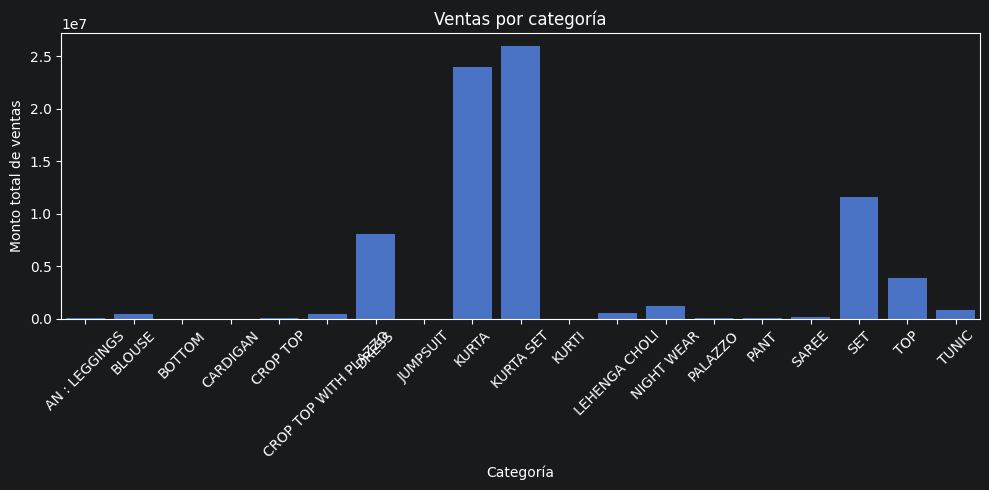

In [11]:
ventas_categoria = fact_ventas.merge(
    dim_producto[["id_producto", "category"]],
    on="id_producto",
    how="left"
).groupby("category", dropna=False)["amount"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_categoria, x="category", y="amount")
plt.title("Ventas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Monto total de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Visualización 2: Tendencia diaria de ventas

Se analiza la evolución diaria del monto de ventas con el fin de identificar variaciones en el comportamiento comercial a lo largo del período disponible en los datos.

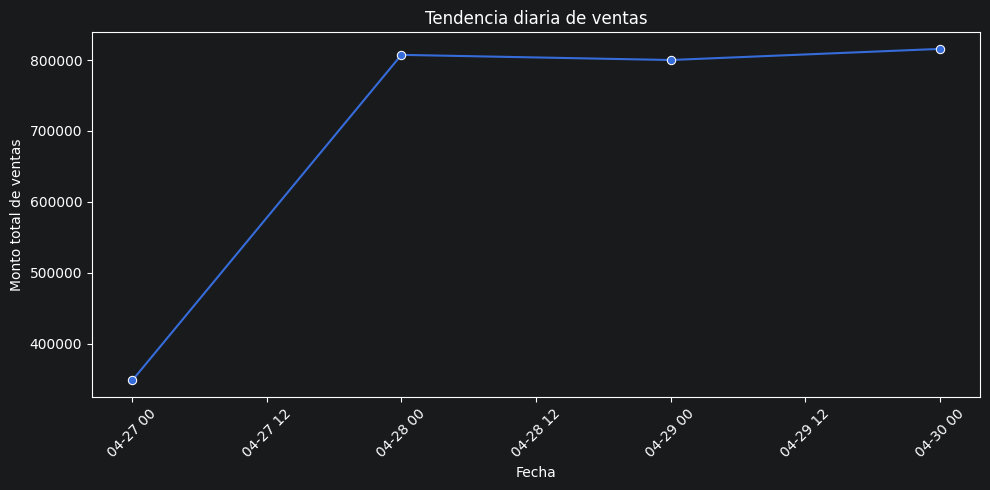

In [12]:
ventas_dia = fact_ventas.merge(
    dim_fecha[["id_fecha", "date"]],
    on="id_fecha",
    how="left"
).groupby("date", dropna=False)["amount"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=ventas_dia, x="date", y="amount", marker="o")
plt.title("Tendencia diaria de ventas")
plt.xlabel("Fecha")
plt.ylabel("Monto total de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretación de la visualización

La tendencia diaria de ventas permite observar la variación del monto vendido durante los días disponibles en el conjunto de datos. Esta visualización facilita identificar días con mayor volumen de ventas y sirve como insumo para analizar comportamiento comercial y posibles patrones temporales.

## Visualización 3: Distribución por tipo de venta

La siguiente visualización resume el peso relativo de cada categoría de venta (`alta`, `media`, `baja`, `sin_dato`), facilitando la segmentación del comportamiento comercial.

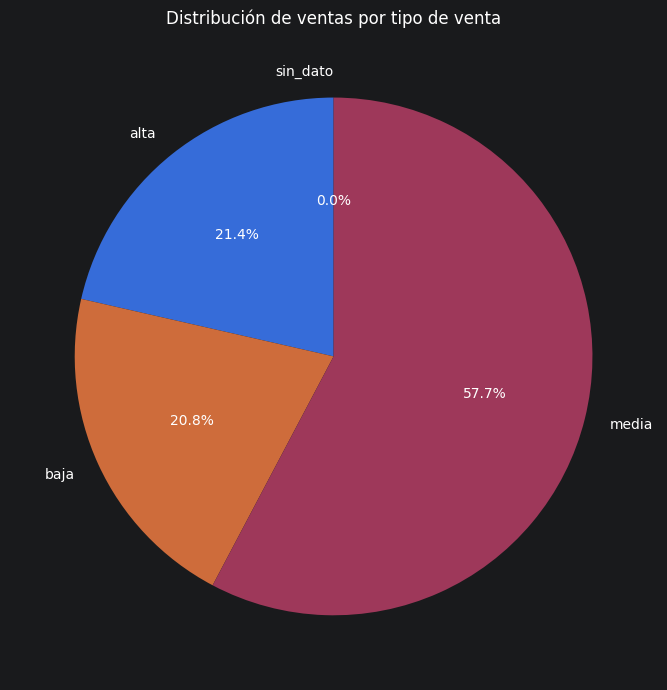

In [13]:
ventas_tipo = fact_ventas.merge(
    dim_tipo_venta[["id_tipo_venta", "tipo_venta"]],
    on="id_tipo_venta",
    how="left"
).groupby("tipo_venta", dropna=False)["amount"].sum().reset_index()

plt.figure(figsize=(7, 7))
plt.pie(
    ventas_tipo["amount"].fillna(0),
    labels=ventas_tipo["tipo_venta"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución de ventas por tipo de venta")
plt.tight_layout()
plt.show()

# Reflexión individual

## Santiago Bravo

Desde mi interés profesional en el área de telecomunicaciones, redes e ISP, considero que esta etapa de carga del proceso ETL tiene una aplicación directa en entornos donde se generan grandes volúmenes de información técnica y operativa. Por ejemplo, en una empresa de servicios de Internet podría utilizarse para cargar de forma periódica datos de tráfico, consumo por cliente, eventos de red, tickets de soporte, inventario de equipos y métricas de disponibilidad hacia una plataforma analítica en la nube. Este proceso permitiría centralizar la información en un repositorio estructurado, facilitar su consulta y mejorar la disponibilidad de reportes para los responsables de operación y gestión.

En un contexto profesional cercano, aplicaría este proceso creando dimensiones como fecha, cliente, equipo o zona, y una tabla de hechos con métricas como consumo, cantidad de incidentes o tiempo de indisponibilidad. La carga automatizada hacia servicios como Amazon S3 y Redshift ayudaría a reducir tareas manuales, mejorar la consistencia de los datos y permitir análisis más rápidos para la toma de decisiones. Considero que este tipo de práctica aporta valor porque transforma datos operativos dispersos en información útil para optimizar el servicio, detectar problemas recurrentes y planificar mejoras de capacidad en la red.

## Alexander Soto

Como Analista SOC, aplicaría este proceso de carga para centralizar eventos de seguridad provenientes de diferentes fuentes como firewalls, antivirus, EDR, correo electrónico, autenticaciones y servicios en la nube, estos datos podrían ser extraídos desde herramientas de monitoreo, transformados mediante procesos ETL para limpiar campos, normalizar fechas, usuarios, direcciones IP, severidades y tipos de alerta, y finalmente cargados en un modelo de datos en la nube, como Amazon Redshift, para facilitar su análisis.

Por ejemplo, podría crear dimensiones como tiempo, usuario, dispositivo, fuente de seguridad y tipo de evento, junto con una tabla de hechos que almacene métricas como cantidad de alertas, severidad, estado del incidente y frecuencia de eventos. Esto permitiría construir dashboards para identificar tendencias, usuarios con mayor número de alertas, horarios con más actividad sospechosa o tecnologías que generan más eventos. De esta forma, el proceso de carga no solo serviría para almacenar información, sino también para mejorar la toma de decisiones, priorizar incidentes y fortalecer la respuesta ante amenazas en el área de ciberseguridad.

## Yordhan Guerron

En mi entorno laboral como asistente en el área de ciberseguridad y análisis de datos, aplicaría este proceso de carga para centralizar información generada por sistemas de seguridad como IDS/IPS, firewalls y registros de red.

Los datos serían transformados previamente en un modelo de estrella, donde las dimensiones representarían elementos como fecha, tipo de alerta y origen del evento, mientras que la tabla de hechos almacenaría los eventos de seguridad con sus métricas principales.

Posteriormente, estos datos serían cargados desde archivos CSV a Amazon S3 y luego integrados en Amazon Redshift para su análisis.

Esto me permitiría generar reportes y visualizaciones para detectar actividades sospechosas, analizar patrones de ataque y mejorar la toma de decisiones en la gestión de incidentes de seguridad.